In [ ]:
import argparse
import numpy as np
seed = 123
np.random.seed(seed)
import random
import torch
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

import pickle

from sklearn import svm
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
import tqdm

In [ ]:
import os
os.chdir('/content/drive/MyDrive/Majorproject/intention')

In [ ]:
def svm_train(train_input, train_output, C_value):
    clf = svm.SVC(C=C_value, gamma='scale', kernel='rbf')

    return clf.fit(train_input, train_output)

In [ ]:
dc = 1
idc = 1000

with open("{}.pickle".format('model_result'), "rb") as f:
  train_dataset, test_dataset = pickle.load(f)

weighted_precision, weighted_recall = [], []
weighted_fscores = []

c_values = [dc for i in range(5)]
c_values.append(1000)
c_values.append(idc)
print("cvalues printing" , c_values)

results = []
for dataset_index in tqdm.trange(7):
  model = svm_train(train_dataset[dataset_index % 6][0], train_dataset[dataset_index % 6][1], c_values[dataset_index])

  pred = model.predict(test_dataset[dataset_index % 6][0])
  label = test_dataset[dataset_index % 6][1]

  result_string = classification_report(label, pred, digits=3)
  print(confusion_matrix(label, pred))
  print(result_string)

  result = classification_report(label, pred, output_dict=True, digits=3)

  weighted_fscores.append(result["weighted avg"]["f1-score"])
  weighted_precision.append(result["weighted avg"]["precision"])
  weighted_recall.append(result["weighted avg"]["recall"])


print("#"*20)
print("Dependent-Avg :")
print("Weighted Precision: {:.3f}  Weighted Recall: {:.3f}  Weighted F score: {:.3f}".format(np.mean(weighted_precision[:5]),
                                                                                                np.mean(weighted_recall[:5]),
                                                                                                np.mean(weighted_fscores[:5])))
print("#"*20)
print("Independent-Avg :")
print("Weighted Precision: {:.3f}  Weighted Recall: {:.3f}  Weighted F score: {:.3f}".format(weighted_precision[-1],
                                                                                                weighted_recall[-1],
                                                                                                weighted_fscores[-1]))

cvalues printing [1, 1, 1, 1, 1, 1000, 1000]


 14%|█▍        | 1/7 [00:01<00:11,  1.84s/it]

[[48 15]
 [13 61]]
              precision    recall  f1-score   support

           0      0.787     0.762     0.774        63
           1      0.803     0.824     0.813        74

    accuracy                          0.796       137
   macro avg      0.795     0.793     0.794       137
weighted avg      0.795     0.796     0.795       137



 29%|██▊       | 2/7 [00:03<00:09,  1.93s/it]

[[44 23]
 [15 56]]
              precision    recall  f1-score   support

           0      0.746     0.657     0.698        67
           1      0.709     0.789     0.747        71

    accuracy                          0.725       138
   macro avg      0.727     0.723     0.723       138
weighted avg      0.727     0.725     0.723       138



...

[[55 22]
 [ 9 51]]
              precision    recall  f1-score   support

           0      0.859     0.714     0.780        77
           1      0.699     0.850     0.767        60

    accuracy                          0.774       137
   macro avg      0.779     0.782     0.774       137
weighted avg      0.789     0.774     0.774       137



 86%|████████▌ | 6/7 [00:12<00:01,  1.91s/it]

[[182  21]
 [ 74  78]]
              precision    recall  f1-score   support

           0      0.711     0.897     0.793       203
           1      0.788     0.513     0.622       152

    accuracy                          0.732       355
   macro avg      0.749     0.705     0.707       355
weighted avg      0.744     0.732     0.720       355



100%|██████████| 7/7 [00:14<00:00,  2.05s/it]

[[43 20]
 [19 55]]
              precision    recall  f1-score   support

           0      0.694     0.683     0.688        63
           1      0.733     0.743     0.738        74

    accuracy                          0.715       137
   macro avg      0.713     0.713     0.713       137
weighted avg      0.715     0.715     0.715       137

####################
Dependent-Avg :
Weighted Precision: 0.759  Weighted Recall: 0.752  Weighted F score: 0.751
####################
Independent-Avg :
Weighted Precision: 0.715  Weighted Recall: 0.715  Weighted F score: 0.715


In [ ]:
import seaborn as sbs
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score      

print(classification_report(label, pred, target_names = ['Intentional','Not Intentional'], digits = 4))

                 precision    recall  f1-score   support

    Intentional     0.6935    0.6825    0.6880        63
Not Intentional     0.7333    0.7432    0.7383        74

       accuracy                         0.7153       137
      macro avg     0.7134    0.7129    0.7131       137
   weighted avg     0.7150    0.7153    0.7151       137



In [ ]:
cm = confusion_matrix(label,pred)
cm

array([[43, 20],
       [19, 55]])

<AxesSubplot:>

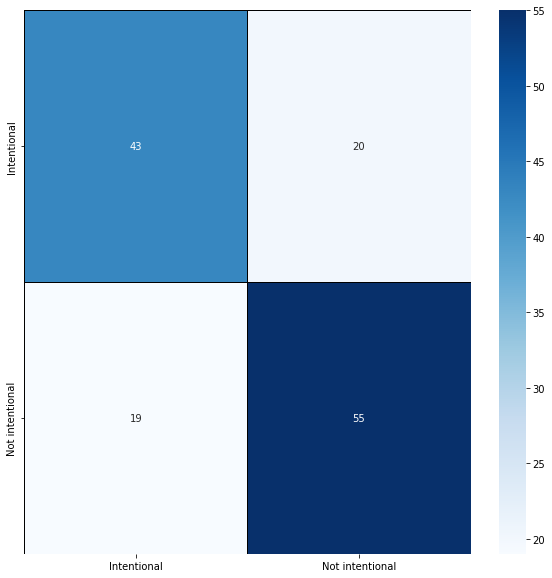

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

cm = pd.DataFrame(cm , index = ['Intentional','Not intentional'] , columns = ['Intentional','Not intentional'])
plt.figure(figsize = (10,10))
sns.heatmap(cm,cmap= "Blues", linecolor = 'black' , linewidth = 1 , annot = True, fmt='' , xticklabels = ['Intentional','Not intentional'] , yticklabels = ['Intentional','Not intentional'])

In [ ]:
dc = 1
idc = 1000

with open("{}.pickle".format('model_result'), "rb") as f:
  train_dataset, test_dataset = pickle.load(f)

weighted_precision, weighted_recall = [], []
weighted_fscores = []

c_values = [dc for i in range(5)]
# c_values.append(1000)
c_values.append(idc)
print("cvalues printing" , c_values)

results = []
for dataset_index in tqdm.trange(5):
  model = svm_train(train_dataset[dataset_index][0], train_dataset[dataset_index][1], c_values[dataset_index])

  pred = model.predict(test_dataset[dataset_index][0])
  label = test_dataset[dataset_index][1]

  result_string = classification_report(label, pred, digits=4)
  print(confusion_matrix(label, pred))
  print(result_string)

  result = classification_report(label, pred, output_dict=True, digits=4)

  weighted_fscores.append(result["weighted avg"]["f1-score"])
  weighted_precision.append(result["weighted avg"]["precision"])
  weighted_recall.append(result["weighted avg"]["recall"])


# print("#"*20)
# print("Average")
# print("Weighted Precision: {:.3f}  Weighted Recall: {:.3f}  Weighted F score: {:.3f}".format(np.mean(weighted_precision[:5]),
#                                                                                                 np.mean(weighted_recall[:5]),
#                                                                                                 np.mean(weighted_fscores[:5])))
print("#"*20)

print("Weighted Precision: {:.3f}  Weighted Recall: {:.3f}  Weighted F score: {:.3f}".format(weighted_precision[-1],
                                                                                                weighted_recall[-1],
                                                                                                weighted_fscores[-1]))

cvalues printing [1, 1, 1, 1, 1, 1000]


 20%|██        | 1/5 [00:02<00:08,  2.03s/it]

[[48 15]
 [13 61]]
              precision    recall  f1-score   support

           0     0.7869    0.7619    0.7742        63
           1     0.8026    0.8243    0.8133        74

    accuracy                         0.7956       137
   macro avg     0.7948    0.7931    0.7938       137
weighted avg     0.7954    0.7956    0.7953       137



 40%|████      | 2/5 [00:03<00:05,  1.88s/it]

[[44 23]
 [15 56]]
              precision    recall  f1-score   support

           0     0.7458    0.6567    0.6984        67
           1     0.7089    0.7887    0.7467        71

    accuracy                         0.7246       138
   macro avg     0.7273    0.7227    0.7225       138
weighted avg     0.7268    0.7246    0.7232       138



...

[[45 30]
 [13 50]]
              precision    recall  f1-score   support

           0     0.7759    0.6000    0.6767        75
           1     0.6250    0.7937    0.6993        63

    accuracy                         0.6884       138
   macro avg     0.7004    0.6968    0.6880       138
weighted avg     0.7070    0.6884    0.6870       138



 80%|████████  | 4/5 [00:07<00:01,  1.93s/it]

[[46 16]
 [15 61]]
              precision    recall  f1-score   support

           0     0.7541    0.7419    0.7480        62
           1     0.7922    0.8026    0.7974        76

    accuracy                         0.7754       138
   macro avg     0.7732    0.7723    0.7727       138
weighted avg     0.7751    0.7754    0.7752       138



100%|██████████| 5/5 [00:09<00:00,  1.92s/it]

[[55 22]
 [ 9 51]]
              precision    recall  f1-score   support

           0     0.8594    0.7143    0.7801        77
           1     0.6986    0.8500    0.7669        60

    accuracy                         0.7737       137
   macro avg     0.7790    0.7821    0.7735       137
weighted avg     0.7890    0.7737    0.7744       137

####################
Weighted Precision: 0.789  Weighted Recall: 0.774  Weighted F score: 0.774


In [ ]:
import seaborn as sbs
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score      

print(classification_report(label, pred, target_names = ['Intentional','Not Intentional'], digits = 4))

                 precision    recall  f1-score   support

    Intentional     0.8594    0.7143    0.7801        77
Not Intentional     0.6986    0.8500    0.7669        60

       accuracy                         0.7737       137
      macro avg     0.7790    0.7821    0.7735       137
   weighted avg     0.7890    0.7737    0.7744       137



<AxesSubplot:>

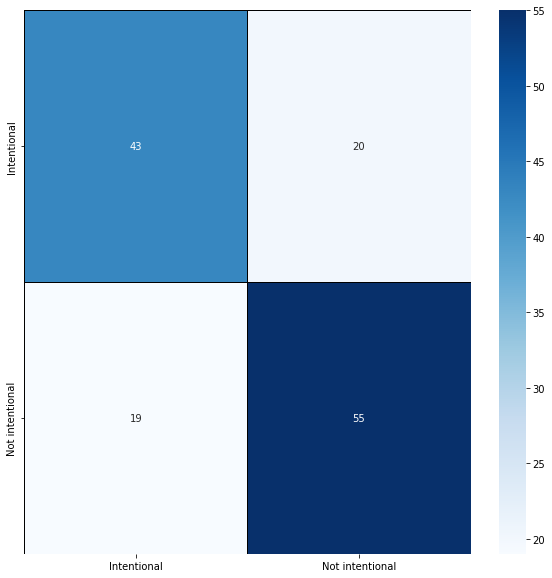

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

cm = pd.DataFrame(cm , index = ['Intentional','Not intentional'] , columns = ['Intentional','Not intentional'])
plt.figure(figsize = (10,10))
sns.heatmap(cm,cmap= "Blues", linecolor = 'black' , linewidth = 1 , annot = True, fmt='' , xticklabels = ['Intentional','Not intentional'] , yticklabels = ['Intentional','Not intentional'])